# Project Summary

This notebook is a short walkthrough of the final analytical output of the project.

**Repo:** [`pandas-dev/pandas`](https://github.com/pandas-dev/pandas)   
**Scope:** Pull Requests, Reviews, Issues, Commits extracted via GitHub REST API → modelled in dbt → 3 engineering KPIs.  
**Data range:** 2025-01-01 onward.

**How to read this notebook**
1. First, a quick overview of the data model.
2. Then, the 3 KPI outputs with short interpretation notes.
3. Finally, an appendix explaining how thresholds were chosen and where they are used later in the KPI logic.

The pipeline works for any public GitHub repository. Just update `REPO_OWNER` and `REPO_NAME` in `extraction/config.py`.

## Data Model

| Layer     | Model                         | Grain |
|-----------|-------------------------------|---|
| Staging   | `stg_pull_requests`           | one row per PR |
| Staging   | `stg_reviews`                 | one row per review |
| Staging   | `stg_issues`                  | one row per issue |
| Staging   | `stg_commits`                 | one row per commit |
| Mart      | `fct_github__pull_requests`   | one row per PR - cycle time, review timing, PR size |
| Mart      | `fct_github__issues`          | one row per issue - resolution time, bug flag |
| Mart      | `dim_github__contributors`    | one row per contributor - activity counts across all entities |
| KPI       | `kpi_cycle_time`              | month × pr_size |
| KPI       | `kpi_time_to_first_review`    | month |
| KPI       | `kpi_bug_resolution_time`     | quarter |
| KPI       | `kpi_bug_resolution_buckets`  | week × resolution bucket |

**Modeling notes**
- **Staging**: basic cleanup, casting, and JSON flattening.
- **Marts**: reusable business logic at a clear fact/dimension grain.
- **KPIs**: pre-computed outputs used directly for analysis.

All timestamps stored UTC in staging, converted to `Europe/Amsterdam` in marts.

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

conn = duckdb.connect("../database/analytics.db")

---
## KPI 1 - PR Cycle Time

**Definition:** median hours from PR opened → merged.   
**Excludes:** draft PRs, bot authors.   
**Large PRs excluded from monthly median** - fewer than 15 per month, insufficient for a statistically stable result.

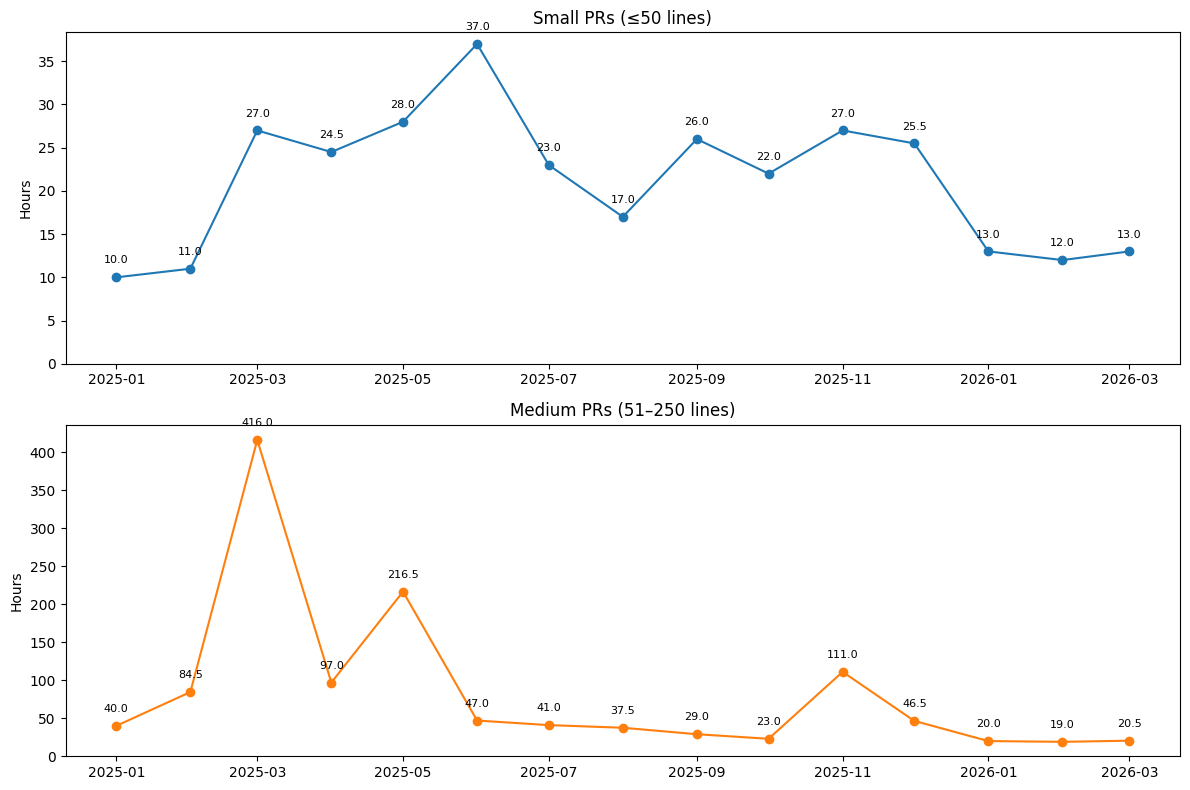

In [2]:
df_cycle = conn.sql("""
    SELECT creation_month, pr_size, median_cycle_time_hours
    FROM main_kpi.kpi_cycle_time
    WHERE median_cycle_time_hours IS NOT NULL
    ORDER BY creation_month, pr_size
""").df()

pivot = df_cycle.pivot(index="creation_month", columns="pr_size", values="median_cycle_time_hours")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

small = pivot["small"]
ax1.plot(small.index, small.values, color="tab:blue", marker="o")
ax1.set_title("Small PRs (≤50 lines)")
ax1.set_ylabel("Hours")
ax1.set_ylim(bottom=0)
ax1.tick_params(axis="x")
for month, val in small.items():
    ax1.annotate(f"{val:.1f}", xy=(month, val), xytext=(0, 10), textcoords="offset points", ha="center", fontsize=8)

medium = pivot["medium"]
ax2.plot(medium.index, medium.values, color="tab:orange", marker="o")
ax2.set_title("Medium PRs (51–250 lines)")
ax2.set_ylabel("Hours")
ax2.set_ylim(bottom=0)
ax2.tick_params(axis="x")
for month, val in medium.items():
    ax2.annotate(f"{val:.1f}", xy=(month, val), xytext=(0, 10), textcoords="offset points", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

**Why this split matters**

PR size is one of the main drivers of cycle time. Looking at one overall median would hide whether changes in the trend come from process speed or just from a different mix of PR sizes.

---
## KPI 2 - Time to First Review

**Definition:** median hours from PR opened → first human review submitted.  
**Excludes:** bot reviewers, PRs with no reviews.  
**24h benchmark:** used as a simple operational reference, roughly one working day.

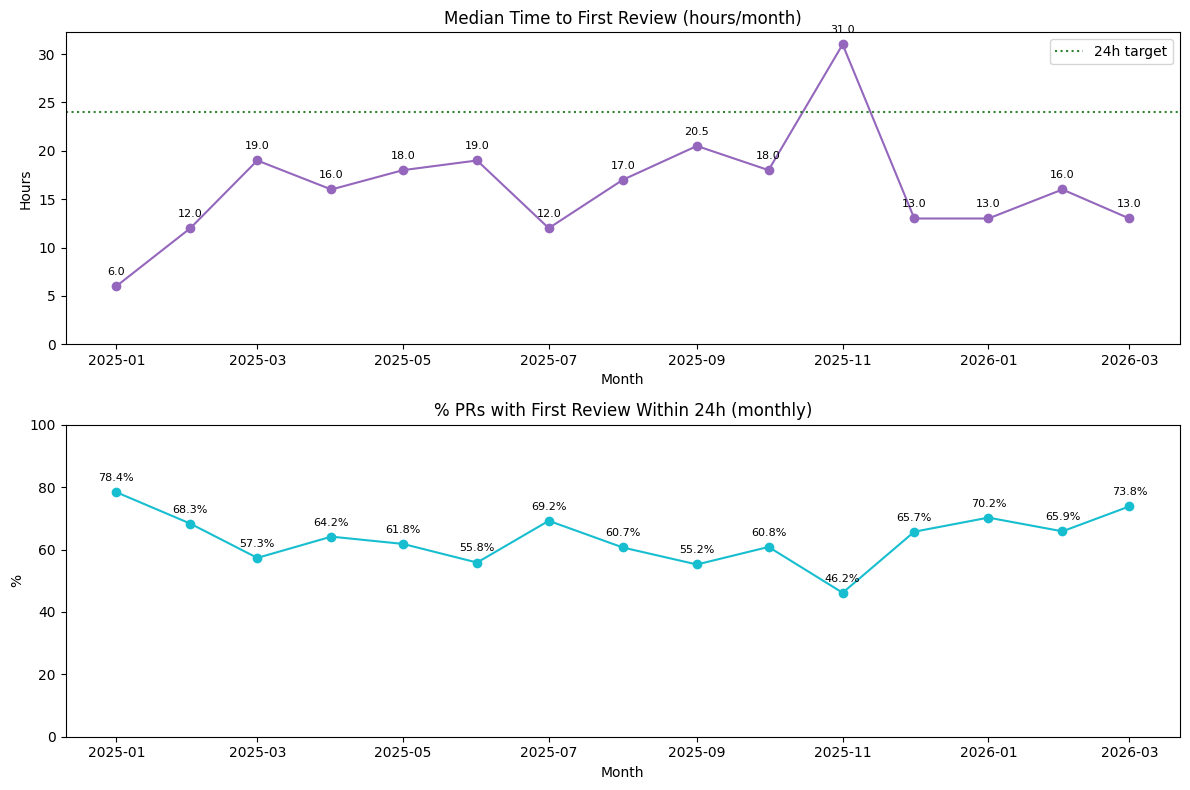

In [3]:
df_review = conn.sql("""
    SELECT
        creation_month,
        median_time_to_first_review_hours,
        pct_reviewed_within_24h
    FROM main_kpi.kpi_time_to_first_review
    ORDER BY creation_month
""").df()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(df_review["creation_month"], df_review["median_time_to_first_review_hours"],
         marker="o", color="tab:purple")
ax1.axhline(24, color="darkgreen", linestyle=":", alpha=0.8, label="24h target")
ax1.set_title("Median Time to First Review (hours/month)")
ax1.set_xlabel("Month")
ax1.set_ylabel("Hours")
ax1.set_ylim(bottom=0)
ax1.tick_params(axis="x")
ax1.legend()
for month, val in zip(df_review["creation_month"], df_review["median_time_to_first_review_hours"]):
    ax1.annotate(f"{val:.1f}", xy=(month, val), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=8)

ax2.plot(df_review["creation_month"], df_review["pct_reviewed_within_24h"]*100,
        marker="o", color="tab:cyan")
ax2.set_title("% PRs with First Review Within 24h (monthly)")
ax2.set_xlabel("Month")
ax2.set_ylabel("%")
ax2.set_ylim(0, 100)
ax2.tick_params(axis="x")
for month, val in zip(df_review["creation_month"], df_review["pct_reviewed_within_24h"]*100):
    ax2.annotate(f"{val:.1f}%", xy=(month, val), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

---
## KPI 3 - Bug Resolution Time

**Definition:** median hours from bug issue opened → closed.  
**Excludes:** bot authors, issues closed as duplicate/wont-fix (completed only).  
**Quarterly grain:** bug volume is low enough that monthly aggregation would be noisy.

The bucket view shows the full distribution: whether bugs close fast, pile up, or trend in either direction over time.

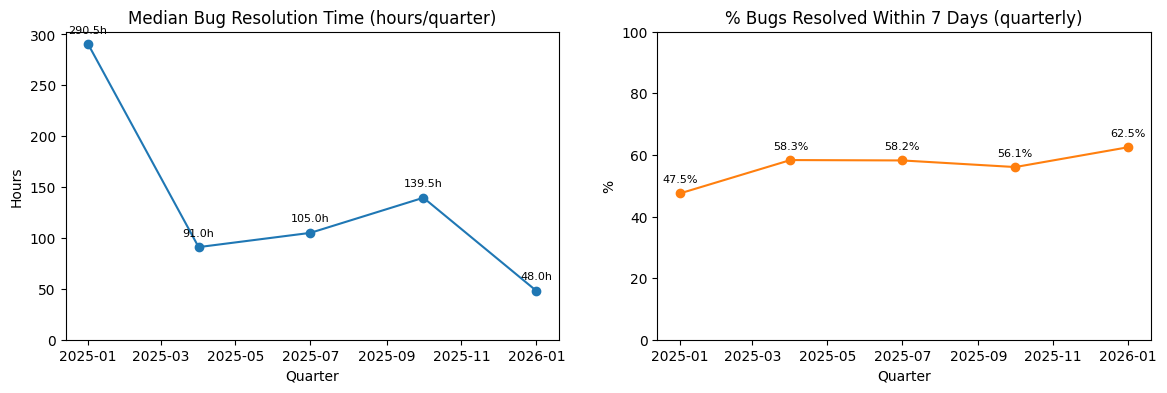

In [4]:
df_bug_time = conn.sql("""
    SELECT creation_quarter, median_hours_to_resolve, pct_resolved_within_7d
    FROM main_kpi.kpi_bug_resolution_time
    ORDER BY creation_quarter
""").df()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(df_bug_time["creation_quarter"], df_bug_time["median_hours_to_resolve"],
         marker="o", color="tab:blue")
ax1.set_title("Median Bug Resolution Time (hours/quarter)")
ax1.set_xlabel("Quarter")
ax1.set_ylabel("Hours")
ax1.set_ylim(bottom=0)
ax1.tick_params(axis="x")
for q, val in zip(df_bug_time["creation_quarter"], df_bug_time["median_hours_to_resolve"]):
    ax1.annotate(f"{val:.1f}h", xy=(q, val), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=8)

ax2.plot(df_bug_time["creation_quarter"], df_bug_time["pct_resolved_within_7d"] * 100,
         marker="o", color="tab:orange")
ax2.set_title("% Bugs Resolved Within 7 Days (quarterly)")
ax2.set_xlabel("Quarter")
ax2.set_ylabel("%")
ax2.set_ylim(0, 100)
ax2.tick_params(axis="x")
for q, val in zip(df_bug_time["creation_quarter"], df_bug_time["pct_resolved_within_7d"] * 100):
    ax2.annotate(f"{val:.1f}%", xy=(q, val), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=8)


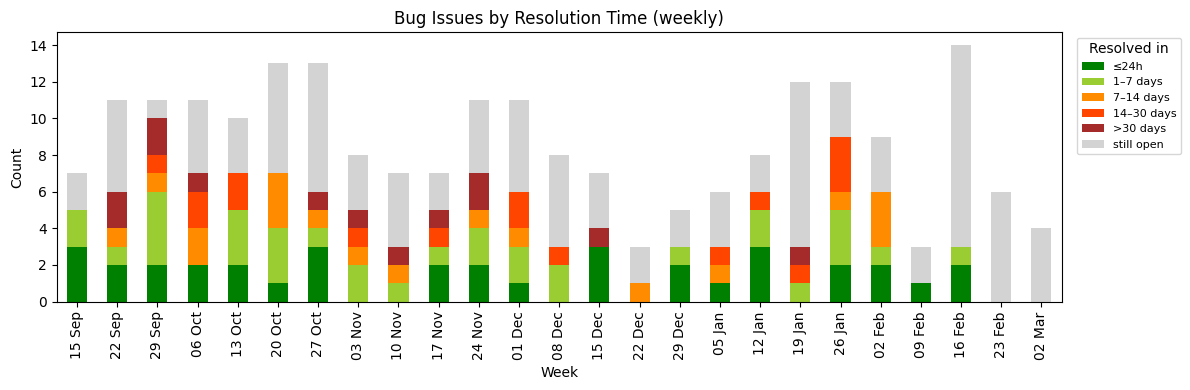

In [5]:
df_bug_bkt = conn.sql("""
    SELECT creation_week, resolution_bucket, bug_count
    FROM main_kpi.kpi_bug_resolution_buckets
    WHERE creation_week >= current_date() - interval 6 months
    ORDER BY creation_week
""").df()

fig, ax = plt.subplots(1, 1, figsize=(12, 4))

bucket_order  = ["within_24h", "within_7_days", "within_14_days", "within_30_days", "over_30_days", "open"]
bucket_labels = ["≤24h", "1–7 days", "7–14 days", "14–30 days", ">30 days", "still open"]
colors        = ["green", "yellowgreen", "darkorange", "orangered", "brown", "lightgrey"]

pivot_bkt = df_bug_bkt.pivot(index="creation_week", columns="resolution_bucket", values="bug_count") \
                      .reindex(columns=bucket_order, fill_value=0)
pivot_bkt.columns = bucket_labels
pivot_bkt.index = pd.to_datetime(pivot_bkt.index).strftime("%d %b")
pivot_bkt.plot(kind="bar", stacked=True, ax=ax, color=colors)
ax.set_title("Bug Issues by Resolution Time (weekly)")
ax.set_xlabel("Week")
ax.set_ylabel("Count")
ax.tick_params(axis="x")
ax.legend(title="Resolved in", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

In [6]:
conn.close()

---
## Appendix - Threshold Selection

How we chose the thresholds used in the KPIs above.

### PR Size Buckets

Thresholds are data-driven, not arbitrary. Percentiles from the actual distribution:

| Boundary | Lines | Rationale |
|---|---|---|
| small / medium | 50 | ~p50 - typical trivial PR |
| medium / large | 250 | ~p90 - focused review effort required above this |

Large PRs (>250 lines) appear fewer than 15 times per month - too few for a reliable monthly median, so they're excluded from `kpi_cycle_time`.

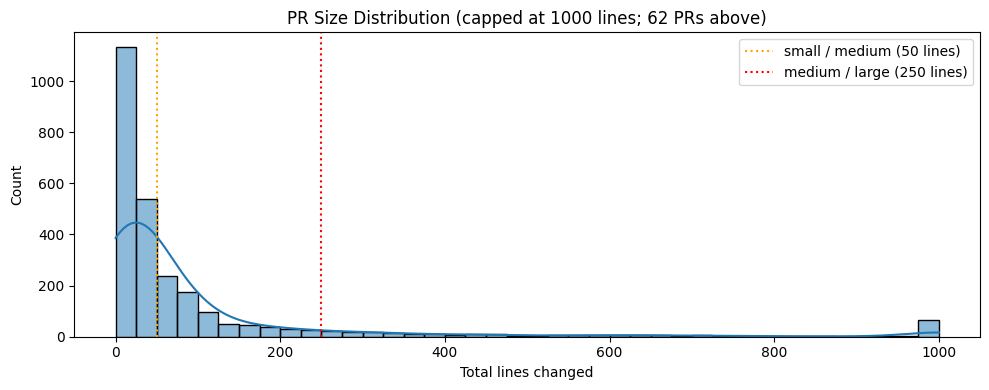

In [7]:
conn2 = duckdb.connect("../database/analytics.db")

df_size = conn2.sql("""
    SELECT total_changes
    FROM main_marts.fct_github__pull_requests
    WHERE total_changes IS NOT NULL
      AND created_at::date >= '2025-01-01'::date
""").df()

capped  = df_size["total_changes"].clip(upper=1000)
n_over  = int((df_size["total_changes"] > 1000).sum())

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(capped, bins=40, kde=True, ax=ax)
ax.axvline(50,  color="orange", linestyle=":", label="small / medium (50 lines)")
ax.axvline(250, color="red",    linestyle=":", label="medium / large (250 lines)")
ax.set_title(f"PR Size Distribution (capped at 1000 lines; {n_over} PRs above)")
ax.set_xlabel("Total lines changed")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

### Cycle Time Outlier Cutoff

PRs open >30 days (~720h) are excluded from `kpi_cycle_time`. They represent stale branches or long-running feature work - not typical workflow.

The distribution is heavily right-skewed: **median ~19h, mean ~65h** (3.5× gap). Median is the right measure - mean is too sensitive to the long tail.

Excluded outliers (>30 days): 83 PRs (5.0% of total)


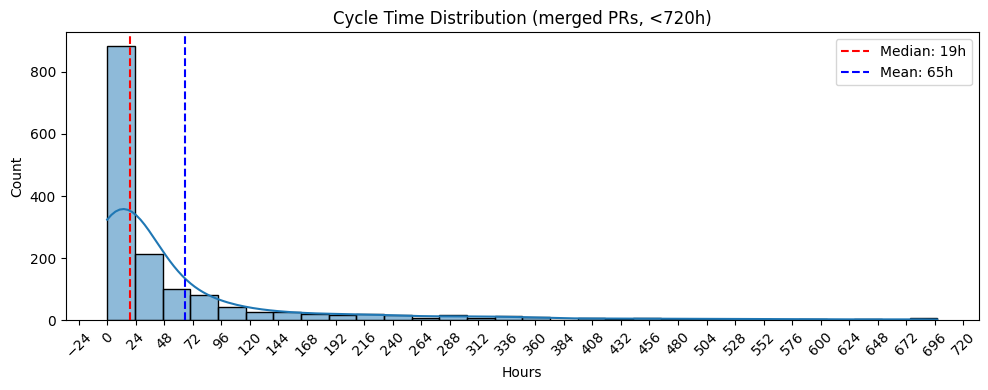

In [8]:
df_cycle_raw = conn2.sql("""
    SELECT cycle_time_hours
    FROM main_marts.fct_github__pull_requests
    WHERE is_merged = true
      AND cycle_time_hours IS NOT NULL
      AND cycle_time_hours < 720
      AND created_at::date >= '2025-01-01'::date
""").df()

n_outliers = conn2.sql("""
    SELECT COUNT(*) AS n
    FROM main_marts.fct_github__pull_requests
    WHERE is_merged = true
      AND cycle_time_hours >= 720
      AND created_at::date >= '2025-01-01'::date
""").df()["n"][0]

total = len(df_cycle_raw) + n_outliers
print(f"Excluded outliers (>30 days): {n_outliers} PRs ({n_outliers / total * 100:.1f}% of total)")

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(df_cycle_raw["cycle_time_hours"], bins=30, kde=True, ax=ax)
ax.axvline(df_cycle_raw["cycle_time_hours"].median(), color="red",  linestyle="--",
           label=f'Median: {df_cycle_raw["cycle_time_hours"].median():.0f}h')
ax.axvline(df_cycle_raw["cycle_time_hours"].mean(),   color="blue", linestyle="--",
           label=f'Mean: {df_cycle_raw["cycle_time_hours"].mean():.0f}h')
ax.xaxis.set_major_locator(ticker.MultipleLocator(24))
ax.tick_params(axis="x", rotation=45)
ax.set_title("Cycle Time Distribution (merged PRs, <720h)")
ax.set_xlabel("Hours")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

### 24h Review Benchmark

Median time to first review is ~16h. 24h sits just above it and represents one full working day - PRs reviewed within 24h didn't experience a meaningful wait. Used as a reference line in KPI 2.

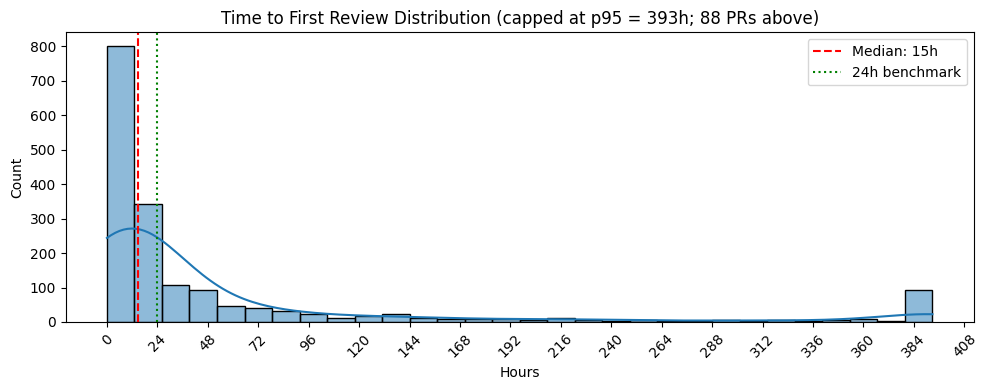

In [9]:
df_rev_raw = conn2.sql("""
    SELECT time_to_first_review_hours
    FROM main_marts.fct_github__pull_requests
    WHERE time_to_first_review_hours IS NOT NULL
      AND created_at::date >= '2025-01-01'::date
""").df()

cap     = df_rev_raw["time_to_first_review_hours"].quantile(0.95)
clipped = df_rev_raw["time_to_first_review_hours"].clip(upper=cap)
n_cap   = int((df_rev_raw["time_to_first_review_hours"] > cap).sum())

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(clipped, bins=30, kde=True, ax=ax)
ax.axvline(clipped.median(), color="red",   linestyle="--",
           label=f'Median: {clipped.median():.0f}h')
ax.axvline(24,               color="green", linestyle=":", label="24h benchmark")
ax.xaxis.set_major_locator(ticker.MultipleLocator(24))
ax.tick_params(axis="x", rotation=45)
ax.set_title(f"Time to First Review Distribution (capped at p95 = {cap:.0f}h; {n_cap} PRs above)")
ax.set_xlabel("Hours")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

### Issues by Label

Shows how issues are distributed across label types - context for the bug KPIs. How big is the bug slice relative to everything else?

In [10]:
df_tags = conn2.sql("""
    SELECT
    label,
    COUNT(*) AS issue_count
FROM main_marts.fct_github__issues,
    UNNEST(label_names) AS t(label)
WHERE created_at::date >= '2025-01-01'::date
GROUP BY 1
ORDER BY 2 DESC
""").df()

display(df_tags)

,label,issue_count
0,Bug,527
1,Needs Triage,231
2,Enhancement,171
3,Docs,154
4,Needs Discussion,103
...,...,...
121,IO XML,1
122,setitem-with-expansion,1
123,Python 3.13,1
124,Non-Unique Columns/Rows,1


### Bug Resolution Distribution

Right-skewed - most bugs close quickly, a long tail drags the mean. Median is the right central measure. The wide spread justifies tracking both a median and a bucket breakdown.

/var/folders/h_/m16nmw1565g8pjmsvp230ln80000gn/T/ipykernel_1145/2585882135.py:11: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  clipped_b = df_bugs_raw["hours_to_close"].clip(upper=cap_b)


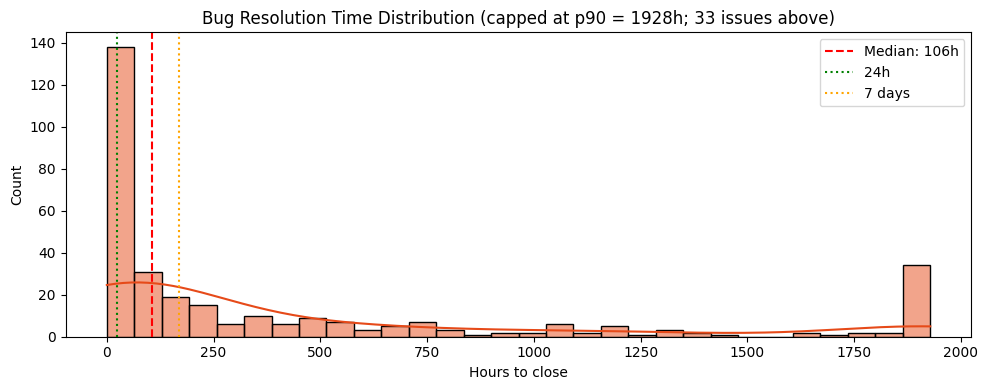

In [11]:
df_bugs_raw = conn2.sql("""
    SELECT hours_to_close
    FROM main_marts.fct_github__issues
    WHERE is_bug = true
      AND is_resolved = true
      AND hours_to_close >= 0
      AND created_at::date >= '2025-01-01'::date
""").df()

cap_b     = df_bugs_raw["hours_to_close"].quantile(0.90)
clipped_b = df_bugs_raw["hours_to_close"].clip(upper=cap_b)
n_cap_b   = int((df_bugs_raw["hours_to_close"] > cap_b).sum())

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(clipped_b, bins=30, kde=True, ax=ax, color="#E64A19")
ax.axvline(clipped_b.median(), color="red",    linestyle="--",
           label=f'Median: {clipped_b.median():.0f}h')
ax.axvline(24,                 color="green",  linestyle=":", label="24h")
ax.axvline(168,                color="orange", linestyle=":", label="7 days")
ax.set_title(f"Bug Resolution Time Distribution (capped at p90 = {cap_b:.0f}h; {n_cap_b} issues above)")
ax.set_xlabel("Hours to close")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
conn2.close()